In [458]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from keras.optimizers import Adam

In [ ]:
beng = pd.read_csv('bengaluru_house_prices.csv')
beng.head()

In [460]:
print(beng.info())
print(beng.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000     

In [461]:
beng.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [462]:
beng = beng.dropna(subset=['location'])

In [463]:
#we will drop availablity as the price is defined by landlord not customer
beng = beng.drop(columns=['availability'])

In [464]:
print(len(beng['society'].unique()))

2689


In [465]:
# for location we will use target encoding
beng['location'] = beng['location'].map(beng.groupby('location')['price'].mean())
beng['location']

,location
0,48.316667
1,115.015882
2,61.252527
3,115.348261
4,95.630303
...,...
13315,128.012324
13316,211.428571
13317,64.714035
13318,140.631429


there are so so much societies and so much missings(nearly half of them) which prevent us from takes a benfit from the column and we will drop it upon this

and from `bath` and `balcony` missings are much less so we will replace  them with median

In [466]:
beng = beng.drop(columns=['society'])
beng['bath'] = beng['bath'].fillna(beng['bath'].median())
beng['balcony'] = beng['balcony'].fillna(beng['balcony'].median())

In [467]:
beng['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [468]:
beng['size'] = beng['size'].dropna().apply(lambda x: x.split()[0]).astype('float')
beng['size'] = beng['size'].fillna(beng['size'].median())

In [469]:
beng.describe()

,location,size,bath,balcony,price
count,13319.000000,13319.000000,13319.000000,13319.000000,13319.000000
mean,112.567621,2.803964,2.688790,1.603349,112.567621
std,93.923153,1.294261,1.338801,0.803090,148.977089
min,15.000000,1.000000,1.000000,0.000000,8.000000
25%,67.666667,2.000000,2.000000,1.000000,50.000000
50%,91.193333,3.000000,2.000000,2.000000,72.000000
75%,125.820208,3.000000,3.000000,2.000000,120.000000
max,1900.000000,43.000000,40.000000,3.000000,3600.000000


In [470]:
# to handle outliers
beng = beng[beng['size']+1 > (beng['bath'])]
beng[beng['size']>15]

,area_type,location,size,total_sqft,bath,balcony,price
1718,Super built-up Area,230.000000,27.0,8000,27.0,0.0,230.0
3379,Super built-up Area,490.000000,19.0,2000,16.0,2.0,490.0
3609,Super built-up Area,575.000000,16.0,10000,16.0,2.0,550.0
4684,Plot Area,120.622083,43.0,2400,40.0,0.0,660.0
11559,Plot Area,200.000000,18.0,1200,18.0,2.0,200.0


In [471]:
# begin just 5 out 14k houses over 15 room means they can't be normal records
beng = beng[beng['size']<15]

In [472]:
# to discover why total_sqft doesn't accept being converted to float

def is_float(x):
  try:
    float(x)
    return True
  except:
    return False

beng.loc[~beng['total_sqft'].apply(is_float),'total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch',
       '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800',
       '1160 - 1195', '4000 - 5249', '1115 - 1130', '1100Sq. Yards',
       '520 - 645', '1000 - 1285', '3606 - 5091', '650 - 665',
       '633 - 666', '5.31Acres', '30Acres', '1445 - 1455', '884 - 1116',
       '850 - 1093', '1440 - 1884', '716Sq. Meter', '547.34 - 827.31',
       '580 - 650', '1804 - 2273', '1500Sq. Meter', '142.61Sq. Meter',
       '2695 - 2940', '2000 - 5634', '1574Sq. Yards', '3450 - 3472',
       '1250 - 1305', '670 - 980', '1005.03 - 1252.49', '1004 - 1204',
       '361.33Sq. Yards', '645 - 936', '2249.81 - 4112.19', '3436 - 3643',
       '596 - 804', '1255 - 1863', '1300 - 1405', '1500 - 2400',
       '117Sq. Yards', '934 - 1437', '980 - 1030', '1564 - 1850',
       '1446 - 1506', '1070 - 1315', '

In [473]:
def clean_ranges(x):

  try:
    return float(x)
  except:
    x = x.split('-')
    return x[0]
  if len(x) == 2:
    try:
      return (float(x[0].strip())+float(x[0].strip()))/2
    except:
      pass

twr = beng['total_sqft'].apply(clean_ranges)
twr[~twr.apply(is_float)].count()

np.int64(40)

In [474]:
# we will neglect these 40 values

beng['total_sqft'] = twr[twr.apply(is_float)].astype("float")
beng = beng.dropna(subset=['total_sqft'])

In [475]:
beng = pd.get_dummies(beng, columns=['area_type'], drop_first=True)
beng.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12361 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   location                        12361 non-null  float64
 1   size                            12361 non-null  float64
 2   total_sqft                      12361 non-null  float64
 3   bath                            12361 non-null  float64
 4   balcony                         12361 non-null  float64
 5   price                           12361 non-null  float64
 6   area_type_Carpet  Area          12361 non-null  bool   
 7   area_type_Plot  Area            12361 non-null  bool   
 8   area_type_Super built-up  Area  12361 non-null  bool   
dtypes: bool(3), float64(6)
memory usage: 712.2 KB


In [476]:
print(beng.describe())
beng.isnull().sum()

           location          size    total_sqft          bath       balcony  \
count  12361.000000  12361.000000  12361.000000  12361.000000  12361.000000   
mean     107.687117      2.733840   1480.217395      2.520832      1.590082   
std       84.443914      1.166008   1175.352625      1.069468      0.796429   
min       15.000000      1.000000      1.000000      1.000000      0.000000   
25%       65.482143      2.000000   1097.000000      2.000000      1.000000   
50%       88.500000      3.000000   1252.000000      2.000000      2.000000   
75%      119.839111      3.000000   1600.000000      3.000000      2.000000   
max     1486.000000     13.000000  52272.000000     13.000000      3.000000   

              price  
count  12361.000000  
mean     100.807652  
std      120.854078  
min        8.000000  
25%       48.760000  
50%       69.000000  
75%      109.000000  
max     2800.000000  


,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0
area_type_Carpet Area,0
area_type_Plot Area,0
area_type_Super built-up Area,0


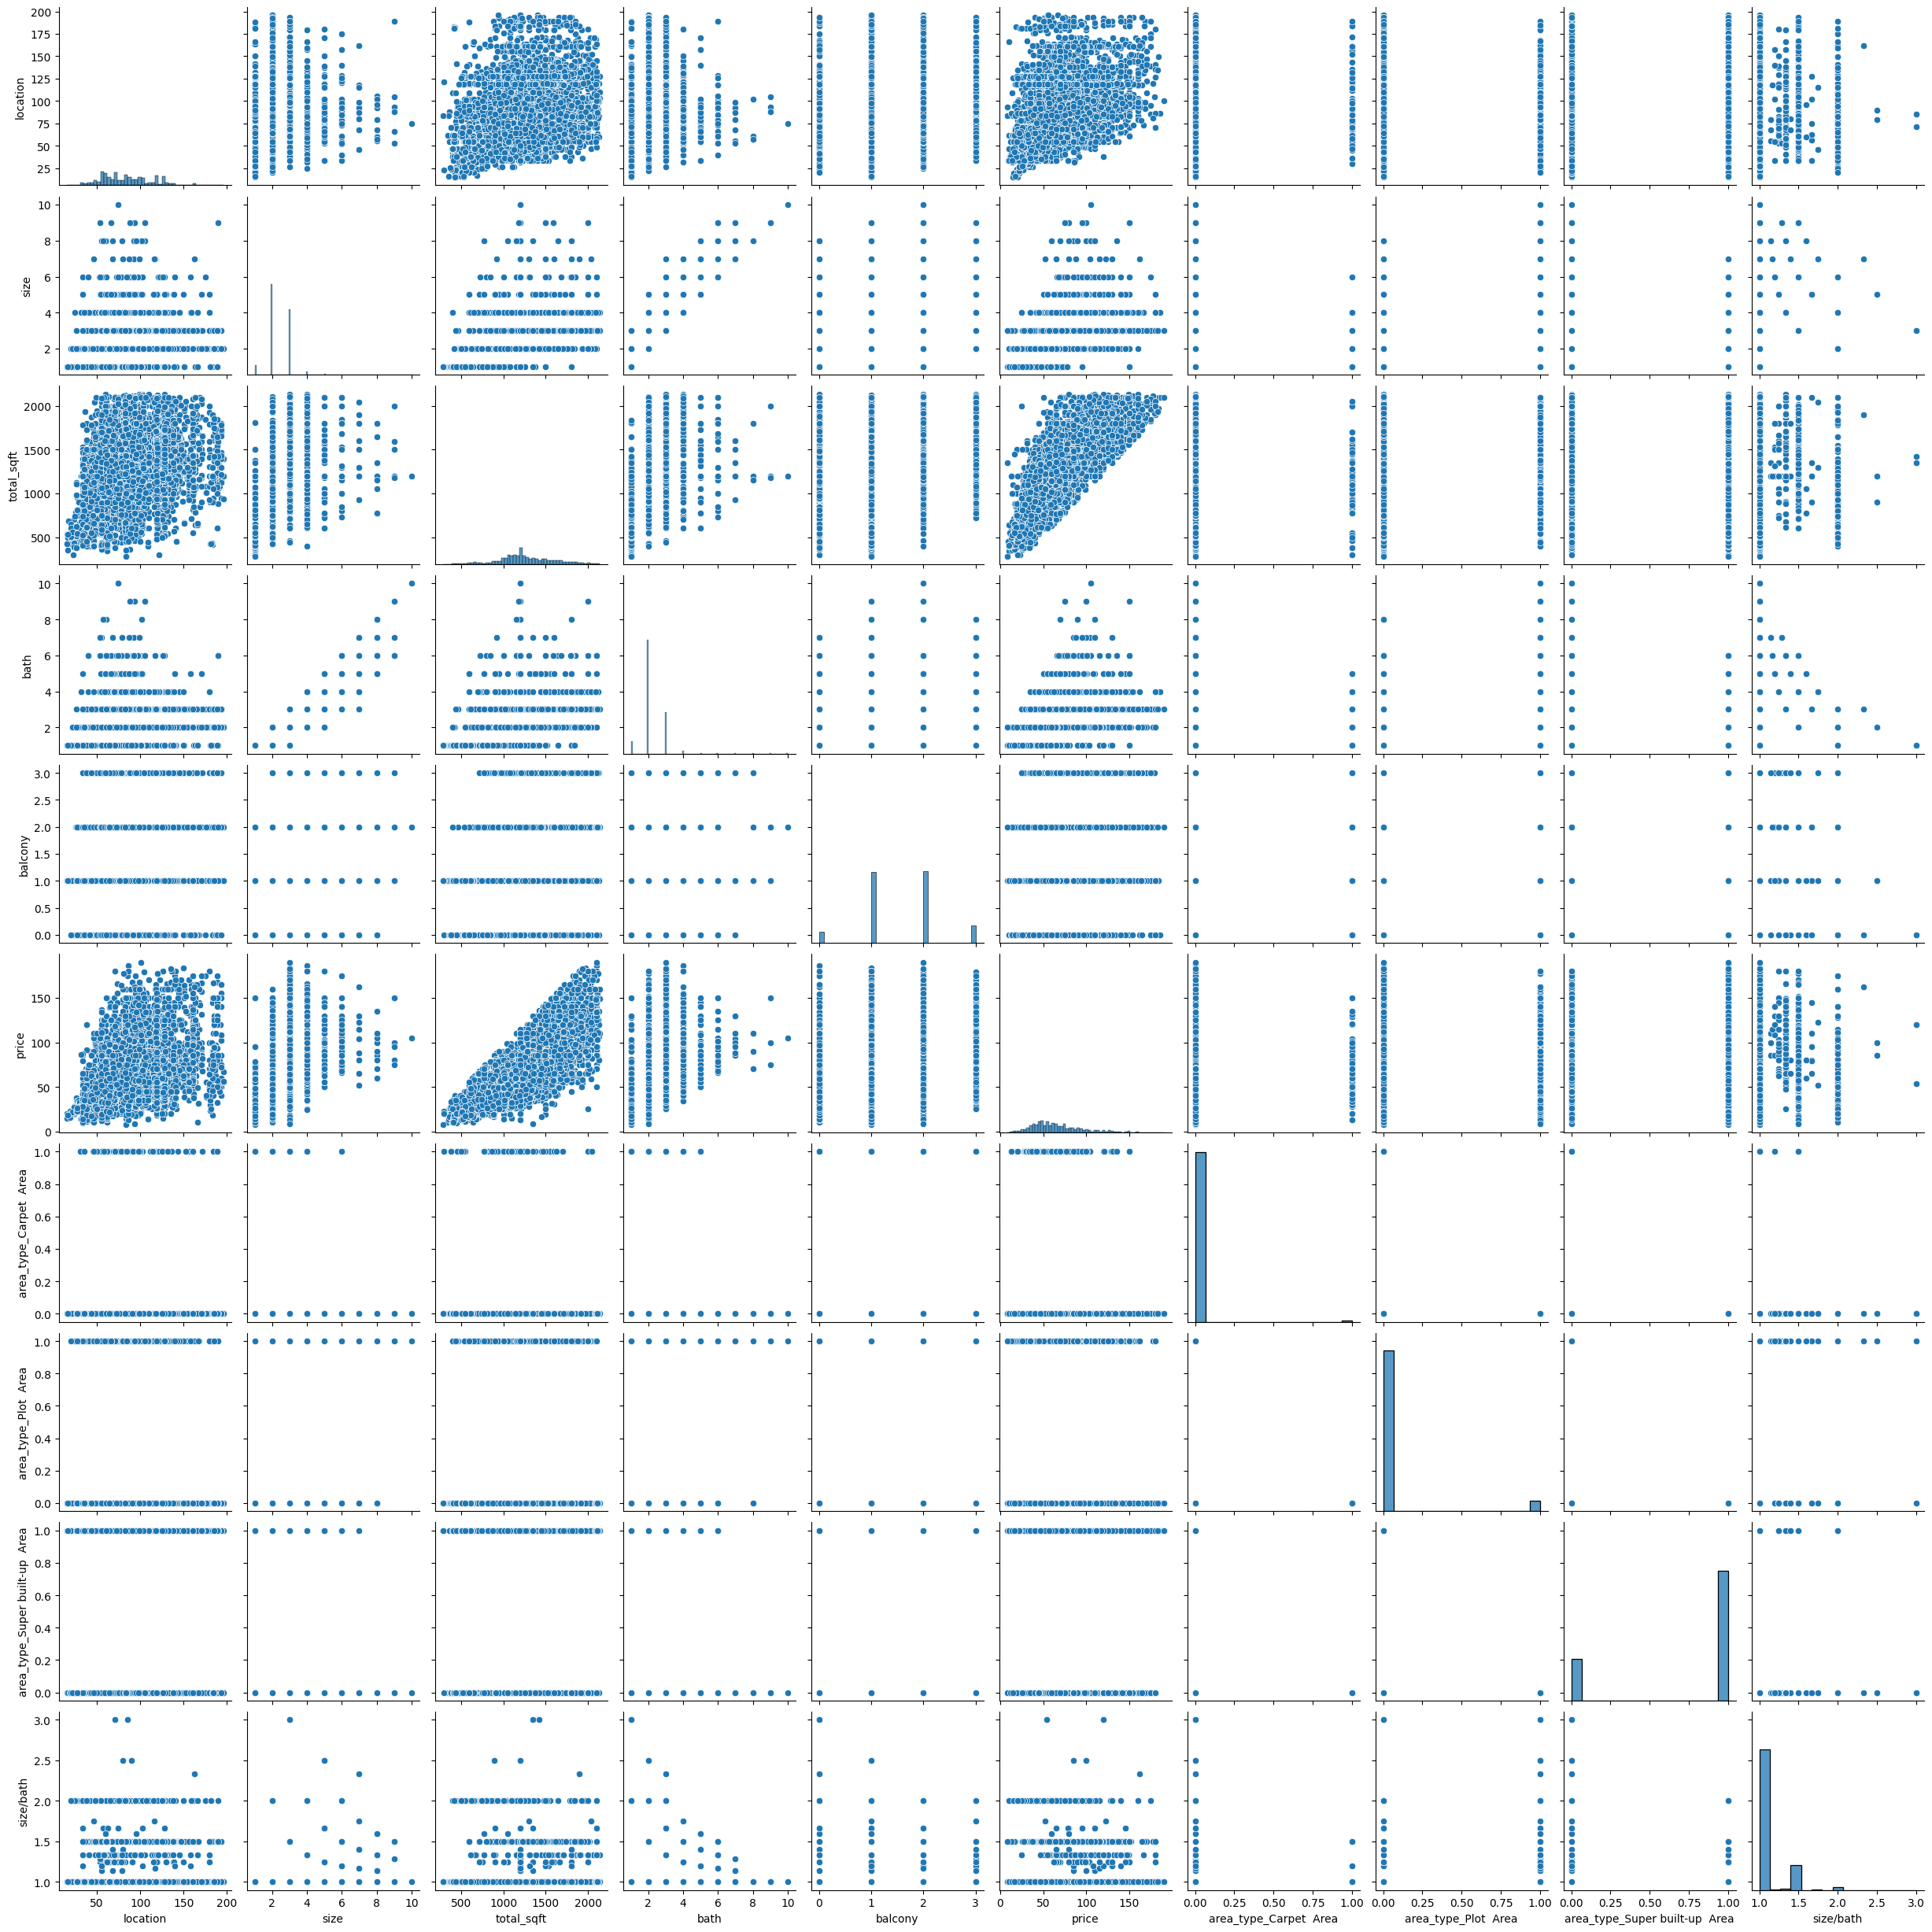

In [492]:
sns.pairplot(beng)

In [478]:
Q1 = beng['price'].quantile(.25)
Q3 = beng['price'].quantile(.75)
IQR = Q3-Q1
upper_limit = Q3+IQR*1.5

beng = beng.loc[beng['price']<upper_limit]
beng = beng.dropna(subset=['price'])


In [479]:
Q1 = beng['location'].quantile(.25)
Q3 = beng['location'].quantile(.75)
IQR = Q3-Q1
upper_limit = Q3+IQR*1.5

beng = beng.loc[beng['location']<upper_limit,]
beng = beng.dropna(subset=['location'])

In [480]:
Q1 = beng['total_sqft'].quantile(.25)
Q3 = beng['total_sqft'].quantile(.75)
IQR = Q3-Q1
upper_limit = Q3+IQR*1.5

beng = beng.loc[beng['total_sqft']<upper_limit]
beng = beng.dropna(subset=['total_sqft'])

In [481]:
beng.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0
area_type_Carpet Area,0
area_type_Plot Area,0
area_type_Super built-up Area,0


In [483]:
beng['size/bath'] = beng['size']/beng['bath']
beng.describe()

,location,size,total_sqft,bath,balcony,price,size/bath
count,9745.000000,9745.000000,9745.000000,9745.000000,9745.000000,9745.000000,9745.000000
mean,86.066396,2.416213,1262.556684,2.233350,1.558338,65.665794,1.095490
std,31.324692,0.741802,322.124811,0.665642,0.762760,28.766355,0.218967
min,15.000000,1.000000,284.000000,1.000000,0.000000,8.000000,1.000000
25%,61.284375,2.000000,1075.000000,2.000000,1.000000,45.000000,1.000000
50%,82.725598,2.000000,1216.000000,2.000000,2.000000,60.000000,1.000000
75%,103.507533,3.000000,1464.000000,3.000000,2.000000,80.000000,1.000000
max,195.800000,10.000000,2137.000000,10.000000,3.000000,190.000000,3.000000


In [484]:
x = beng.drop(columns='price')
y = beng['price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15 ,random_state=23)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15 ,random_state=23)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

print(x_train.shape)
print(x_test.shape)
print(x_val.shape)
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(7040, 9)
(1462, 9)
(1243, 9)
(7040,)
(1462,)
(1243,)


In [485]:
model = Sequential()

model.add(Input(shape=(9,)))
model.add(Dense(20,activation='relu'))
model.add(Dense(12,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1,activation='linear'))

In [488]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [489]:
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_val,y_val), verbose=1, batch_size=20)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 257.6582 - val_loss: 272.9584
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 256.6511 - val_loss: 271.7292
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 255.1395 - val_loss: 272.1513
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 254.5222 - val_loss: 279.4699
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 254.1939 - val_loss: 272.2426
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 253.1969 - val_loss: 271.8417
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 252.8813 - val_loss: 273.6490
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 251.6382 - val_loss: 270.7823
Epoch 9/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 251.7773 - val_loss: 275.1406
Epoch 10/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 251.3381 - val_loss: 276.1651
Epoch 11/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 251.4483 - val_loss: 274.3652
Epoch 12

In [490]:
y_hat = model.predict(x_test)
print(r2_score(y_test,y_hat))
print('-'*20)
print("didn't have the time to do more please accept it")

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
0.6950352957615757
--------------------
didn't have the time to do more please accept it
